In [56]:
!pip install matplotlib numpy pandas


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [57]:
!pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


사전 준비 — 한글 포트 등록

In [58]:
!mkdir -p fonts
!wget -q https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf \
    -O fonts/NanumGothic.ttf

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
fm.fontManager.addfont('fonts/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 음수 부호 깨짐 방지

공통 데이터 — 고정 시드로 생성

In [59]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(13)  # 숙제 번호 13을 시드로 (재현 가능성)

N = 150
genre = rng.choice(['뉴스', '소설', '대화', '학술'], size=N, p=[0.3, 0.3, 0.2, 0.2])
base = {'뉴스': 22, '소설': 18, '대화': 9, '학술': 28}  # 장르별 평균 어절 수
words = (np.array([base[g] for g in genre]) + rng.normal(0, 5, N)).clip(3, 60)
words = words.round().astype(int)
syllables = (words * 2.5 + rng.normal(0, 4, N)).clip(5, None).round().astype(int)
read_time = (syllables * 0.35 + rng.normal(0, 1.5, N)).clip(1, None).round(1)
difficulty = (words * 0.15 + rng.normal(0, 1.2, N)).clip(1, 10).round(1)

texts = pd.DataFrame({
    '장르': genre,
    '어절수': words,
    '음절수': syllables,
    '읽기시간': read_time,
    '난이도': difficulty,
})

# 연도별 신문/소설의 외래어 비율(%) (가상 데이터)
trends = pd.DataFrame({
    '연도': [1990, 1995, 2000, 2005, 2010, 2015, 2020],
    '뉴스': [5.1, 6.3, 8.0, 9.4, 11.2, 13.5, 15.1],
    '소설': [3.2, 3.5, 4.0, 4.6, 5.1, 5.8, 6.4],
})

Q1. matplotlib 기본 그래프 세 가지

(a) 막대 그래프: 장르별 문장 수

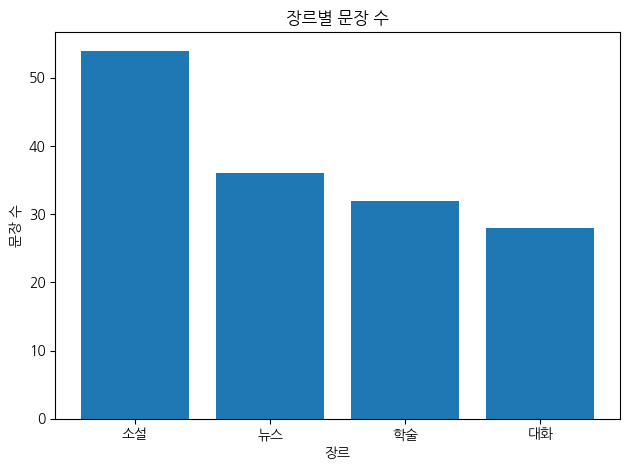

In [60]:
genre_counts = texts['장르'].value_counts()  # 장르별 문장 수 집계

fig, ax = plt.subplots()
ax.bar(genre_counts.index, genre_counts.values)  # x: 장르명, y: 문장 수
ax.set_title('장르별 문장 수')
ax.set_xlabel('장르')
ax.set_ylabel('문장 수')
ax.set_ylim(0)  # y축 0부터 시작
plt.tight_layout()
plt.show()

설명:
texts['장르'].value_counts()로 장르별 문장 수를 집계한 후 ax.bar로 막대 그래프를 그렸다. set_ylim(0)으로 y축을 0부터 시작해 막대 길이의 차이를 명확히 비교할 수 있다. 소설 장르의 문장 수가 가장 많고, 대화 장르의 문장 수가 가장 적은 것을 알 수 있다.

(b) 히스토그램: 어절 수 분포

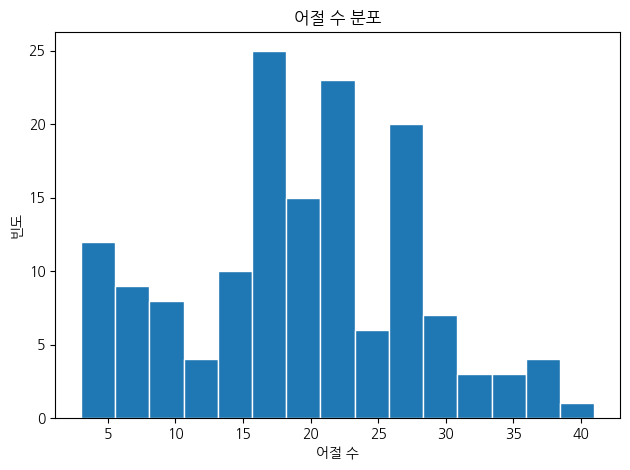

In [61]:
fig, ax = plt.subplots()
ax.hist(texts['어절수'], bins=15, edgecolor='white')  # bins=15로 구간 수 조절, 경계선 흰색
ax.set_title('어절 수 분포')
ax.set_xlabel('어절 수')
ax.set_ylabel('빈도')
plt.tight_layout()
plt.show()

설명:
ax.hist로 어절수의 분포를 그리고, bins=15로 구간 수를 조절하였다. edgecolor='white'로 막대 경계를 표시해 각 구간을 구분하기 쉽게 하였다.

관찰:
어절 수는 약 15~25 구간에 집중되어 있으며, 이는 매우 길거나 짧은 문장보다 중간 정도 되는 문장이 많은 것으로 해석할 수 있다.

(c) 산점도: 음절 수와 읽기 시간

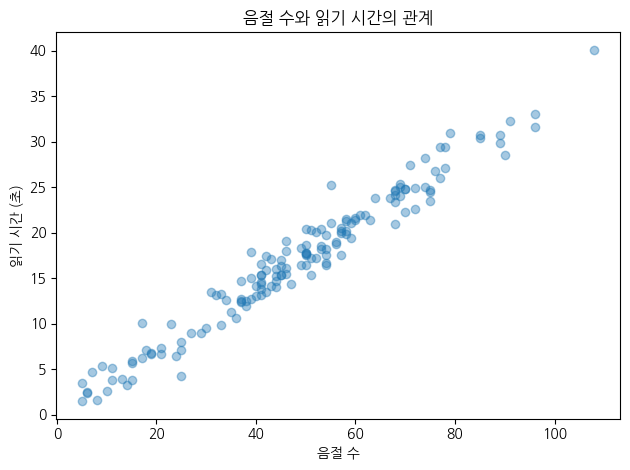

In [62]:
fig, ax = plt.subplots()
ax.scatter(texts['음절수'], texts['읽기시간'], alpha=0.4)  # alpha로 투명도 조절, 점 겹침 시 밀도 파악 가능
ax.set_title('음절 수와 읽기 시간의 관계')
ax.set_xlabel('음절 수')
ax.set_ylabel('읽기 시간 (초)')
plt.tight_layout()
plt.show()

설명:
ax.scatter로 x축을 음절수, y축을 읽기 시간으로 설정하였다. alpha=0.4로 투명도를 낮춰 점의 밀도를 파악할 수 있도록 하였다.

관찰:
음절 수가 많을수록 읽기 시간도 길어지는 우상향 관계를 보이는 것을 확인할 수 있다.

Q2. 선 그래프와 서브플롯

(a) 여러 선 그래프: 연도별 외래어 비율

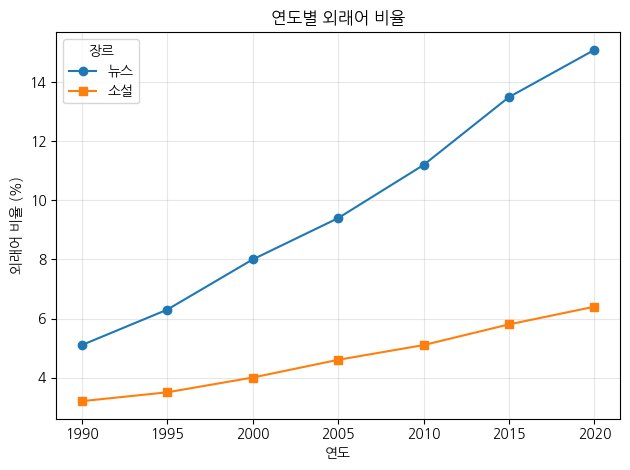

In [63]:
fig, ax = plt.subplots()

# 뉴스와 소설 두 장르를 한 Axes에 선 그래프로 표시
ax.plot(trends['연도'], trends['뉴스'], marker='o', label='뉴스')
ax.plot(trends['연도'], trends['소설'], marker='s', label='소설')

ax.set_title('연도별 외래어 비율')
ax.set_xlabel('연도')
ax.set_ylabel('외래어 비율 (%)')
ax.legend(title='장르')          # 범례에 장르 제목 표시
ax.grid(True, alpha=0.3)         # 연한 격자 표시
plt.tight_layout()
plt.show()

설명:
trends 데이터를 사용해 뉴스와 소설의 외래어 비율 변화를 하나의 Axes에 선 그래프로 나타내었다. 각 선에 marker와 label을 지정하고 ax.legend(title='장르')로 범례를, ax.grid(True, alpha=0.3)로 연한 격자를 추가하였다.

관찰:
두 장르 모두 외래어 비율이 꾸준히 증가하는 추세를 보이는데, 뉴스 장르의 외래어 비율이 소설보다 전반적으로 높으며, 증가 속도도 더 빠른 것을 확인할 수 있다.

(b) 서브플롯: 한 Figure에 네 그래프

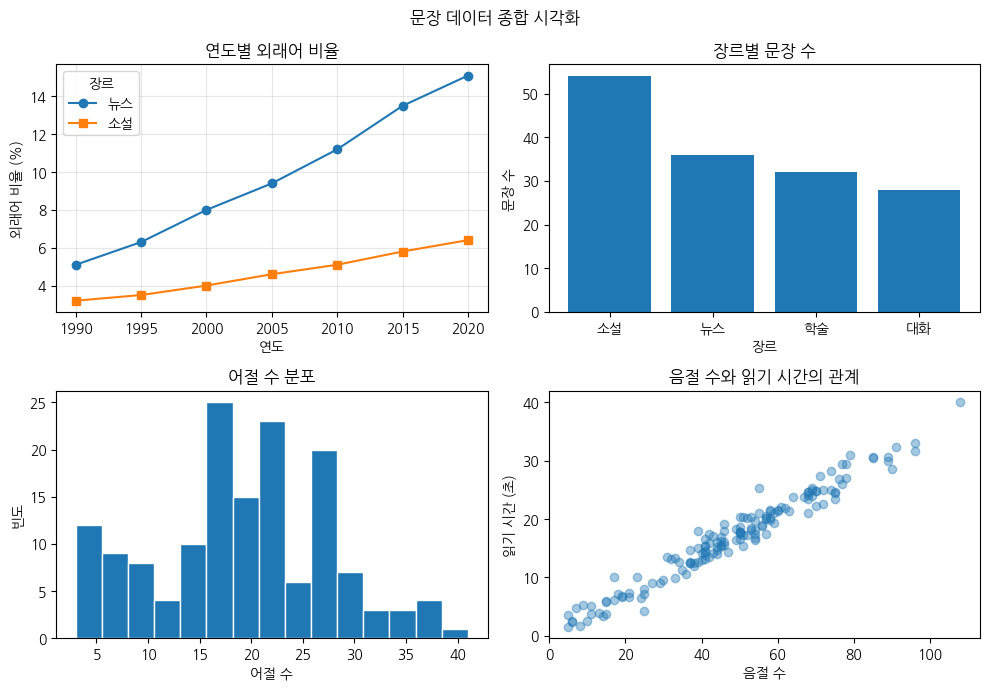

In [64]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))  # 2×2 격자 생성

# axes[0, 0]: Q2(a)의 선 그래프
axes[0, 0].plot(trends['연도'], trends['뉴스'], marker='o', label='뉴스')
axes[0, 0].plot(trends['연도'], trends['소설'], marker='s', label='소설')
axes[0, 0].set_title('연도별 외래어 비율')
axes[0, 0].set_xlabel('연도')
axes[0, 0].set_ylabel('외래어 비율 (%)')
axes[0, 0].legend(title='장르')
axes[0, 0].grid(True, alpha=0.3)

# axes[0, 1]: Q1(a)의 막대 그래프
genre_counts = texts['장르'].value_counts()
axes[0, 1].bar(genre_counts.index, genre_counts.values)
axes[0, 1].set_title('장르별 문장 수')
axes[0, 1].set_xlabel('장르')
axes[0, 1].set_ylabel('문장 수')
axes[0, 1].set_ylim(0)

# axes[1, 0]: Q1(b)의 히스토그램
axes[1, 0].hist(texts['어절수'], bins=15, edgecolor='white')
axes[1, 0].set_title('어절 수 분포')
axes[1, 0].set_xlabel('어절 수')
axes[1, 0].set_ylabel('빈도')

# axes[1, 1]: Q1(c)의 산점도
axes[1, 1].scatter(texts['음절수'], texts['읽기시간'], alpha=0.4)
axes[1, 1].set_title('음절 수와 읽기 시간의 관계')
axes[1, 1].set_xlabel('음절 수')
axes[1, 1].set_ylabel('읽기 시간 (초)')

fig.suptitle('문장 데이터 종합 시각화')  # 전체 제목
fig.tight_layout()                        # 서브플롯 간 겹침 방지

fig.savefig('hw13_subplots.png', dpi=150, bbox_inches='tight')  # PNG 파일로 저장
plt.show()

설명:
plt.subplots(2, 2, figsize=(10, 7))로 2×2 격자를 만들어 Q1, Q2의 네 그래프를 한 Figure에 배치하였다. fig.suptitle()로 전체 제목을 달고, fig.tight_layout()으로 서브플롯 간 겹침을 방지하였다. fig.savefig()로 hw13_subplots.png에 저장해 GitHub에 함께 commit할 수 있도록 하였다.

Q3. seaborn으로 그룹과 관계 보기

(a) scatterplot: 장르별 색칠

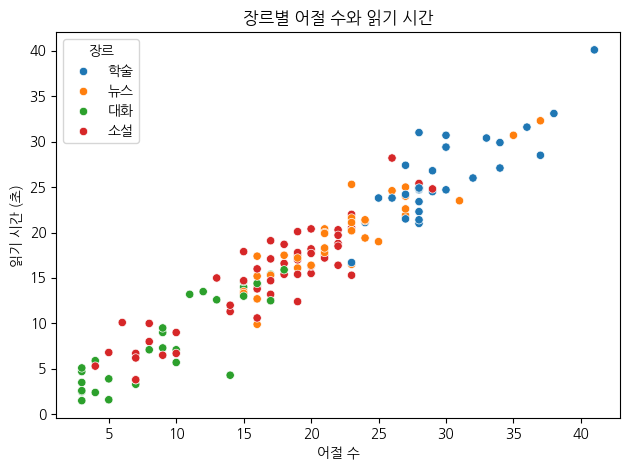

In [65]:
import seaborn as sns

# (a) scatterplot: 장르별 색칠
fig, ax = plt.subplots()
sns.scatterplot(data=texts, x='어절수', y='읽기시간', hue='장르', ax=ax)  # hue로 장르별 색 자동 구분
ax.set_title('장르별 어절 수와 읽기 시간')
ax.set_xlabel('어절 수')
ax.set_ylabel('읽기 시간 (초)')
plt.tight_layout()
plt.show()

설명:
sns.scatterplot으로 x축을 어절수, y축을 읽기시간으로 설정하고 hue='장르'로 장르별 색을 자동으로 구분시켰다. ax=ax로 fig, ax = plt.subplots()에서 만든 ax에 연동하여 객체지향 방식으로 그렸다.

(b) boxplot: 장르별 난이도 분포

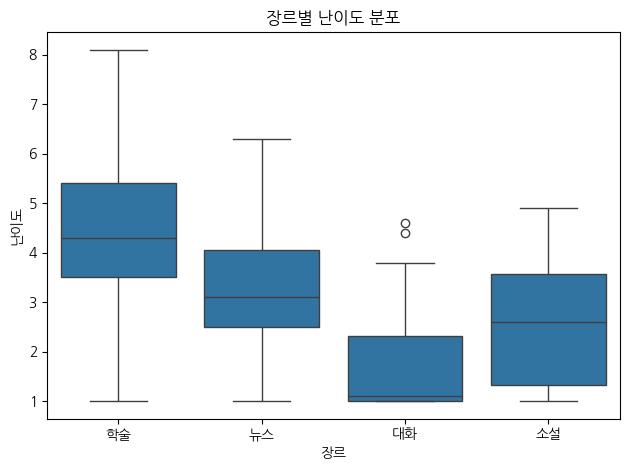

In [66]:
fig, ax = plt.subplots()
sns.boxplot(data=texts, x='장르', y='난이도', ax=ax)  # 장르별 난이도 분포를 상자그림으로 표시
ax.set_title('장르별 난이도 분포')
ax.set_xlabel('장르')
ax.set_ylabel('난이도')
plt.tight_layout()
plt.show()

설명:
sns.boxplot으로 x축을 장르, y축을 난이도로 설정해 장르별 난이도 분포를 상자그림으로 나타내었다. 상자의 크기로 각 장르 내 난이도의 퍼짐 정도를, 중앙선으로 중앙값을 비교할 수 있다.

관찰:
학술 장르가 가장 높은 난이도를 보이며, 소설 장르가 퍼짐(상자의 크기)이 가장 크다.

(c) heatmap: 변수 간 상관계수

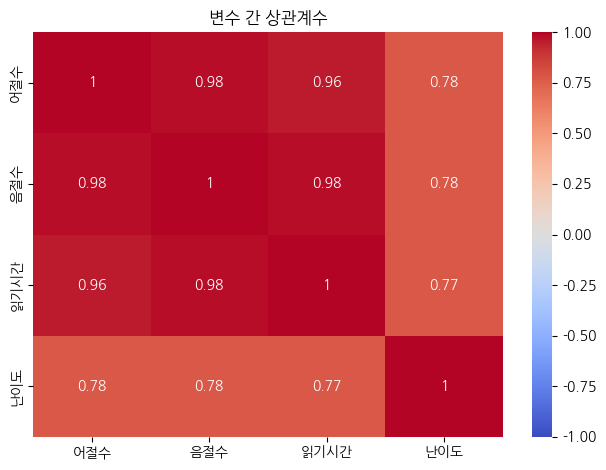

In [67]:
corr = texts[['어절수', '음절수', '읽기시간', '난이도']].corr()  # 네 숫자 열의 상관계수 행렬 계산

fig, ax = plt.subplots()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax)  # annot=True로 숫자 표시
ax.set_title('변수 간 상관계수')
plt.tight_layout()
plt.show()

설명:
texts의 네 숫자 열에 대해 .corr()로 상관계수 행렬을 구한 뒤 sns.heatmap으로 시각화하였다. annot=True로 각 셀에 수치를 표시하고, cmap='coolwarm'과 vmin=-1, vmax=1로 색상 범위를 설정하였다.

관찰:
어절수-음절수(0.98)와 음절수-읽기시간(0.98)이 가장 강한 양의 상관관계를 보인다. 이는 어절이 많을수록 음절이 많아지고, 음절이 많아지면 읽는 시간도 길어지는 데이터의 구조적 특성을 반영한다.

Q4. 정직한 그래프 (비판적으로 보기)

(a) 막대(평균) vs. 상자그림: 무엇이 숨겨지는가

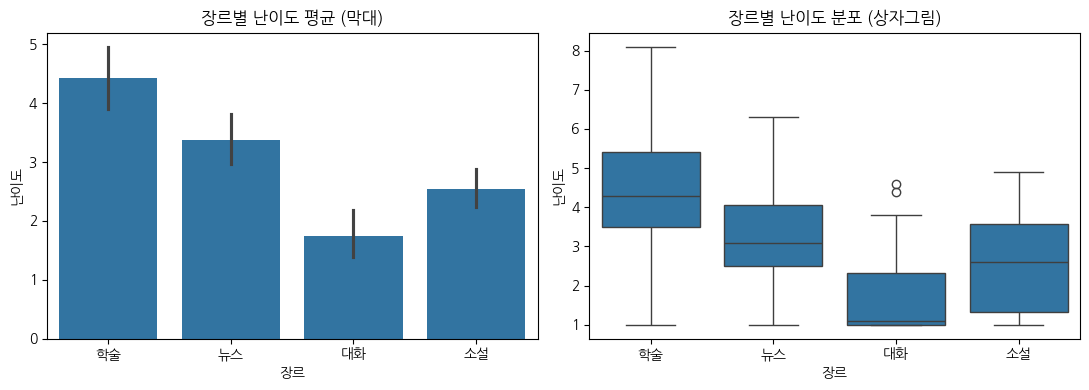

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# 왼쪽: 장르별 난이도 평균 막대 그래프
sns.barplot(data=texts, x='장르', y='난이도', ax=axes[0])  # 평균값만 표시
axes[0].set_title('장르별 난이도 평균 (막대)')
axes[0].set_xlabel('장르')
axes[0].set_ylabel('난이도')

# 오른쪽: 장르별 난이도 분포 상자그림
sns.boxplot(data=texts, x='장르', y='난이도', ax=axes[1])  # 분포 전체를 표시
axes[1].set_title('장르별 난이도 분포 (상자그림)')
axes[1].set_xlabel('장르')
axes[1].set_ylabel('난이도')

fig.tight_layout()
plt.show()

설명: 
plt.subplots(1, 2)로 두 그래프를 나란히 배치하고, 왼쪽에는 sns.barplot, 오른쪽에는 sns.boxplot을 그렸다. 같은 데이터를 두 방식으로 시각화하여 평균만 보여주는 막대 그래프의 한계를 상자그림으로 보완했다.

서술:
왼쪽 막대 그래프("다이너마이트 플롯")는 장르별 평균값만 보여주기 때문에 각 장르 내부의 분포 형태, 이상치, 퍼짐 정도를 전혀 알 수 없는 것에 반해, 오른쪽 상자그림은 중앙값, 사분위 범위, 이상치까지 한눈에 보여준다. 또한, 소설 장르와 대화 장르처럼 평균이 비슷하더라도 소설은 분포가 넓게 퍼져 있는 반면 대화는 분포가 매우 좁고 낮은 난이도에 집중되어 있음을 관찰할 수 있다.

(b) y축 자르기의 함정

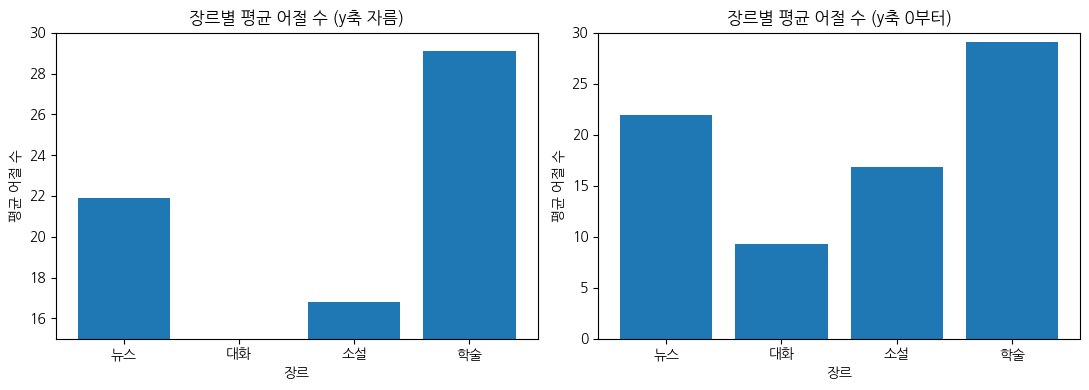

In [69]:
mean_words: pd.Series = texts.groupby('장르')['어절수'].mean()  # 장르별 평균 어절 수 계산

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# 왼쪽: y축을 잘라서 그린 막대 그래프, 차이가 과장되어 보임
axes[0].bar(mean_words.index, mean_words.values)
axes[0].set_ylim(15, 30)  # y축을 잘라서 차이를 과장
axes[0].set_title('장르별 평균 어절 수 (y축 자름)')
axes[0].set_xlabel('장르')
axes[0].set_ylabel('평균 어절 수')

# 오른쪽: y축을 0부터 그린 막대 그래프, 실제 차이를 정직하게 표현
axes[1].bar(mean_words.index, mean_words.values)
axes[1].set_ylim(0, 30)  # y축을 0부터 시작해 정직하게 표현
axes[1].set_title('장르별 평균 어절 수 (y축 0부터)')
axes[1].set_xlabel('장르')
axes[1].set_ylabel('평균 어절 수')

fig.tight_layout()
plt.show()

설명:
groupby('장르')['어절수'].mean()으로 장르별 평균 어절 수를 구한 뒤 동일한 데이터를 두 막대 그래프로 나란히 그렸다. 왼쪽은 set_ylim(15, 30)으로 y축을 잘라 차이를 과장하였고, 오른쪽은 set_ylim(0, 30)으로 0부터 시작해 실제 차이를 정직하게 표현하였다.

서술:
y축을 15에서 시작한 왼쪽 그래프는 장르 간 차이가 매우 크게 보이고, 0부터 시작한 오른쪽 그래프에서는 실제 차이가 크지 않음을 알 수 있다. 심지어 왼쪽 막대 그래프의 경우 대화 장르의 평균 어절 수는 보이지 않는 것을 알 수 있다. 막대 그래프는 막대의 길이로 크기를 비교하는 시각화 자료이므로 y축을 반드시 0부터 시작해야 독자에게 왜곡된 인상을 주지 않는다.

생성형 AI 참조 링크: https://claude.ai/share/da06f5b1-3cbb-4aa2-a10c-ea5da115508c